# NinaPro DB7: 40-class EMG + IMU recognition

**98% is the target, not a measured or guaranteed result.** Run the notebook on
the actual DB7 files to obtain the held-out score. There are no prefilled scores
or pretrained weights. The final report explicitly says whether the target was met.

## v1.1 accuracy-oriented update

The completed v1.0 run reported **97.965% raw held-out window accuracy** and
**99.50% whole-repetition accuracy** on subjects 1–20. This v1.1 notebook adds
validation ensembles matched to the final two-seed ensemble,
a broader SVM search, and a validation-selected **causal** trailing-probability
filter. It reports raw and causal window scores separately. Since v1.0's test
scores are already known, the v1.1 result on repetitions 2/5 is a retrospective
comparison, not an untouched confirmation. A new acquisition is required for a
fresh final claim.

This is **subject-specific, offline classification of presegmented active movements**.
It is not a test on unseen people, rest detection, or continuous prosthetic control.
Inputs are 12 EMG channels and 36 channels each of accelerometer, gyroscope, and
magnetometer data. **No glove signals or label/subject/repetition IDs enter the model.**

## Kaggle setup

1. Create a Kaggle notebook and import this `.ipynb`.
2. Attach the original **DB7 synchronized preprocessed** MAT files for subjects
   **1–20**, or their `Subject_*.zip` archives, using **Add Input**. There must be
   two exercise files per subject. Get them from the
   [official DB7 page](https://ninapro.hevs.ch/instructions/DB7.html).
3. Select a GPU accelerator. The neural component uses one available CUDA GPU;
   SVM and ExtraTrees run on CPU. CPU execution also works, but is slower.
4. Set `DATA_ROOT` below to your attached DB7 folder. `Run All`.
   The notebook uses Kaggle's installed packages and works with Internet off
   when the data are attached. Do not install a different CUDA PyTorch.
5. Results and models are saved under `/kaggle/working/db7_results_v11`.

An optional official-download cell is included for Internet-enabled sessions.
The complete dataset is large; attaching a Kaggle dataset avoids repeated downloads.
This notebook embeds all implementation code; no extra Python upload is required.

### Subject 18 metadata recovery

This version fixes the reported stop at `S18_E1_A1.mat`. The explicit setting
`filename_subject_overrides=(18,)` uses subject 18's filename identity if its
embedded MAT subject number disagrees, and records both values in
`recording_metadata.json`. It does not rewrite signals or labels. Exercise
IDs, filename/folder conflicts, other subject IDs, signal shapes, and class
coverage are still checked. All MAT subject/exercise headers are now checked
before model training starts. The actual embedded subject value is printed;
this recovery policy does not establish whether the source annotation or file
provenance is at fault.

V1.1 changes the model-selection protocol, so run it in its new output folder.
It preserves the completed v1.0 result folder rather than reusing old models.

## Fixed evaluation protocol

| Phase | Repetitions | Purpose |
|---|---|---|
| Development training | 1, 3, 4 | Fit models and normalizers |
| Validation | 6 | Choose modalities, window length, SVM settings, neural epochs, ensemble weights |
| Final refit | 1, 3, 4, 6 | Refit the frozen recipe |
| Held-out comparison | 2, 5 | Evaluate after validation selection |

Each subject gets a separate model. The default cohort is all 20 intact subjects;
it must not be reduced after viewing test performance. Subject 21 has only 38
movements and cannot enter this 40-class protocol. Subject 22 can be evaluated
in a separate configured experiment; amputee results are reported separately.

Use `restimulus` with `rerepetition`. Exercise-local label ranges are mapped to
40 unique classes using `(exercise, original label)` and saved in `label_map`.
Rest is excluded. All six repetitions of all classes must have usable windows.

**Windowing:** compare 500 and 1,000 ms, stride 100 ms. Windows stay entirely
inside one contiguous active label/repetition interval. All candidate lengths
use the same decision endpoints, beginning one maximum-length window after each
interval starts. This allows a fair duration comparison but excludes transition
windows and intervals shorter than the maximum window. Exclusions are logged.
No additional central-only trimming is used. The 500/1,000 ms observation times
prioritize offline accuracy and may be too slow for a responsive controller.

Overlapping windows from one repetition never cross splits. Filtering happens
inside each window; learned normalization sees training data only. The SVM uses
no random internal probability-calibration folds. Test labels are used for
segmentation, integrity checks, and final metrics, never model selection.

In [1]:
from pathlib import Path
import importlib
import importlib.metadata
import json
import sys

WORK_ROOT = Path('/kaggle/working')
WORK_ROOT.mkdir(parents=True, exist_ok=True)
for package in ('numpy', 'scipy', 'sklearn', 'torch', 'h5py', 'joblib', 'matplotlib'):
    importlib.import_module(package)  # Fail early on missing/binary-incompatible packages.
print('Runtime imports passed. Python:', sys.version.split()[0])

Runtime imports passed. Python: 3.12.13


## Embedded implementation

Features summarize EMG amplitude, waveform changes, sign changes, spectral bands,
and four temporal subwindows. IMU features retain orientation and motion with
mean, standard deviation, range, endpoint change, and subwindow means.
EMG uses a 20–450 Hz bandpass; IMUs use a 20 Hz low-pass on the synchronized grid.

The candidate ensemble combines an RBF SVM, ExtraTrees, and a PyTorch residual
network with a separate feature branch for each modality. EMG+accelerometer and
EMG+all IMUs are compared on validation. Full IMU information is available without
assuming every modality improves every subject. Validation and final neural/tree
components both average fixed seeds 42 and 137. Ensemble weights may select one
component alone. A causal trailing mean of current/past probabilities is selected
on repetition 6; it resets at a known active-trial boundary and has no future input.

The next cell writes the embedded, inspectable module used by the notebook.

In [2]:
%%writefile /kaggle/working/ninapro_db7.py
"""NinaPro DB7: subject-specific, repetition-held-out 40-class recognition.

No glove, subject ID, exercise ID, repetition, time index, or labels enter a model.
The notebook embeds this module so a single .ipynb is sufficient on Kaggle.
"""
from __future__ import annotations

import argparse
import contextlib
import gc
import hashlib
import importlib.metadata
import itertools
import json
import math
from pathlib import Path
import random
import re
import shutil
import tempfile
import time
import urllib.request
import zipfile
from dataclasses import asdict, dataclass

import h5py
import joblib
import numpy as np
from scipy import io, signal
from scipy.special import softmax
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score, confusion_matrix, f1_score, log_loss
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

VERSION = "1.1.0"
# Model/features are unchanged, so existing inference bundles and completed
# experiments remain compatible. Track this loader-only fix separately.
LOADER_VERSION = "1.0.1"
MODALITIES = ("emg", "acc", "gyro", "mag")
CHANNELS = {"emg": 12, "acc": 36, "gyro": 36, "mag": 36}
N_CLASSES = 40


@dataclass
class Config:
    data_root: str = "/kaggle/input"
    output_root: str = "/kaggle/working/db7_results"
    subjects: tuple = tuple(range(1, 21))
    fs: int = 2000
    window_ms: tuple = (500, 1000)
    stride_ms: int = 100
    train_reps: tuple = (1, 3, 4)
    val_reps: tuple = (6,)
    test_reps: tuple = (2, 5)
    # All sensor channels are retained within each modality. No glove option.
    modality_sets: tuple = (("emg", "acc"), MODALITIES)
    # gamma_factor=1 is close to RBF gamma="scale" after modality balancing.
    svm_grid: tuple = ((1.0, 0.25), (10.0, 0.25), (10.0, 0.5), (10.0, 1.0),
                       (100.0, 0.25), (100.0, 0.5), (100.0, 1.0))
    tree_count: int = 400
    max_epochs: int = 120
    patience: int = 18
    batch_size: int = 256
    lr: float = 8e-4
    weight_decay: float = 1e-3
    final_seeds: tuple = (42, 137)
    # Match the validation ensemble to the final refit ensemble.
    validation_seeds: tuple = (42, 137)
    # Causal trailing-probability spans at the 100 ms decision spacing.
    smoothing_spans: tuple = (1, 3, 5, 7, 9, 15)
    seed: int = 42
    use_neural: bool = True
    workers: int = 2
    feature_batch: int = 32
    target: float = 0.98
    cache_features: bool = True
    resume: bool = True
    # Explicit recovery for the reported S18 filename/MAT subject mismatch.
    # The original embedded value is preserved in the metadata audit.
    filename_subject_overrides: tuple = (18,)

    def validate(self):
        groups = [set(self.train_reps), set(self.val_reps), set(self.test_reps)]
        if any(not g for g in groups) or any(groups[i] & groups[j] for i in range(3) for j in range(i)):
            raise ValueError("Train, validation, and test repetition sets must be nonempty and disjoint.")
        if set.union(*groups) != set(range(1, 7)):
            raise ValueError("Every repetition 1..6 must belong to exactly one split.")
        if not self.subjects or len(set(self.subjects)) != len(self.subjects):
            raise ValueError("Select at least one subject, without duplicates.")
        if any(s not in range(1, 23) or s == 21 for s in self.subjects):
            raise ValueError("Subjects must be 1..22 except 21, who has only 38 classes.")
        if any(s not in range(1, 23) for s in self.filename_subject_overrides):
            raise ValueError("Filename subject overrides must use subject IDs 1..22.")
        if self.fs != 2000:
            raise ValueError("This configuration expects the synchronized 2 kHz DB7 release.")
        if not self.window_ms or min(self.window_ms) < 100 or self.stride_ms <= 0:
            raise ValueError("Use windows >=100 ms and a positive stride.")
        if any((ms * self.fs) % 1000 for ms in (*self.window_ms, self.stride_ms)):
            raise ValueError("Windows and stride must correspond to integer sample counts.")
        if any(not g or len(set(g)) != len(g) or set(g) - set(MODALITIES) or "emg" not in g for g in self.modality_sets):
            raise ValueError("Each modality set must include emg and only the four allowed signals.")
        if (not self.svm_grid or self.max_epochs < 1 or self.tree_count < 1 or
                not self.final_seeds or not self.validation_seeds):
            raise ValueError("Model search and training settings must be positive/nonempty.")
        if tuple(self.validation_seeds) != tuple(self.final_seeds):
            raise ValueError("Validation and final ensemble seeds must match in the same order.")
        if any(not isinstance(span, int) or span < 1 or span % 2 == 0 for span in self.smoothing_spans):
            raise ValueError("Smoothing spans must be positive odd integers.")


def write_json(path, value):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    temp = path.with_suffix(path.suffix + ".tmp")
    temp.write_text(json.dumps(value, indent=2, allow_nan=False), encoding="utf-8")
    temp.replace(path)


def digest(value):
    return hashlib.sha256(json.dumps(value, sort_keys=True).encode()).hexdigest()[:20]


def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True


@dataclass(frozen=True)
class Recording:
    path: str
    member: str | None
    subject: int
    exercise: int

    def fingerprint(self):
        stat = Path(self.path).stat()
        value = [str(Path(self.path).resolve()), stat.st_size, stat.st_mtime_ns, self.member]
        if self.member:
            with zipfile.ZipFile(self.path) as archive:
                info = archive.getinfo(self.member)
                value += [info.CRC, info.file_size]
        return value


def parse_identity(name):
    name = name.replace("\\", "/")
    s = re.search(r"(?:^|[/_ -])s(?:ubject)?[_ -]?0*(\d+)(?=[/_. -]|$)", name, re.I)
    e = re.search(r"(?:^|[/_ -])e(?:xercise)?[_ -]?0*(\d+)(?=[/_. -]|$)", name, re.I)
    if s and e:
        return int(s.group(1)), int(e.group(1))
    return None


def discover_recordings(data_root, subjects):
    root = Path(data_root)
    if not root.is_dir():
        raise FileNotFoundError(f"Data folder does not exist: {root}. Attach DB7 to the Kaggle notebook.")
    requested = set(subjects)
    found = {}
    # Prefer an extracted MAT to its identical archived copy; never load both.
    paths = sorted(p for p in root.rglob("*") if p.is_file() and p.suffix.lower() in {".mat", ".zip"})
    for path in paths:
        if path.suffix.lower() == ".zip":
            with zipfile.ZipFile(path) as archive:
                names = [n for n in archive.namelist() if n.lower().endswith(".mat") and "__MACOSX" not in n]
        else:
            names = [None]
        for member in names:
            identity = parse_identity(str(path.parent / member) if member else str(path))
            if identity is None and member:
                identity = parse_identity(str(path) + "/" + member)
            if identity is None or identity[0] not in requested:
                continue
            item = Recording(str(path), member, *identity)
            old = found.get(identity)
            if old and bool(old.member) == bool(member):
                raise ValueError(f"Duplicate recording for {identity}: {old} and {item}. Set data_root to one DB7 copy.")
            if old is None or member is None:
                found[identity] = item
    missing = [s for s in subjects if len([k for k in found if k[0] == s]) != 2]
    if missing:
        raise ValueError(f"Need exactly two exercise MAT files for each subject. Missing/extra exercises: {missing}. "
                         "Expected names such as S1_E1_A1.mat / S1_E2_A1.mat, possibly inside Subject_1.zip. "
                         "Attach the original synchronized DB7 files; do not substitute DB2 or EMG-only CSVs.")
    return {s: sorted([r for r in found.values() if r.subject == s], key=lambda r: r.exercise) for s in subjects}


@contextlib.contextmanager
def materialize(recording, temporary_root):
    if recording.member is None:
        yield Path(recording.path)
        return
    Path(temporary_root).mkdir(parents=True, exist_ok=True)
    # Copy exactly one known member into a task-owned temporary directory.
    # No archive paths are extracted, so ../ archive traversal cannot occur.
    with tempfile.TemporaryDirectory(prefix="db7_", dir=temporary_root) as folder:
        target = Path(folder) / "recording.mat"
        with zipfile.ZipFile(recording.path) as archive, archive.open(recording.member) as src, target.open("wb") as dst:
            shutil.copyfileobj(src, dst, length=4 * 1024 * 1024)
        yield target


def read_mat_variables(path, wanted):
    """Read only requested variables; header preflight never loads signals."""
    if h5py.is_hdf5(path):
        with h5py.File(path, "r") as f:
            # MATLAB v7.3 reverses the HDF5 storage dimension order.
            data = {k.lower(): np.asarray(f[k]).T for k in f if k.lower() in wanted}
    else:
        names = [k for k, _, _ in io.whosmat(path) if k.lower() in wanted]
        data = {k.lower(): v for k, v in io.loadmat(path, variable_names=names).items() if k.lower() in wanted}
    return data


def validate_recording_metadata(recording, data, cfg, announce=True):
    """Keep exercise checks strict; allow explicitly named subject annotations.

    Filename authority is a documented recovery policy, not proof that the
    recording's provenance is correct. Conflicting filenames/folders still fail.
    """
    expected = (recording.subject, recording.exercise)
    source = (recording.member or recording.path).replace("\\", "/")
    filename_identity = parse_identity(source.rsplit("/", 1)[-1])
    if filename_identity is not None and filename_identity != expected:
        raise ValueError(f"Recording filename identity {filename_identity} disagrees with {expected}: {recording}")
    # Inspect both archive/directory names and nested archive folders, when
    # they explicitly carry a Subject_N / SN identity.
    identity_parts = recording.path.replace("\\", "/").split("/")[:-1]
    if recording.member:
        identity_parts += [Path(recording.path).stem] + source.split("/")[:-1]
    for part in identity_parts:
        match = re.fullmatch(r"(?:subject|s)[_ -]?0*(\d+)", part, re.I)
        if match and int(match.group(1)) != recording.subject:
            raise ValueError(f"Conflicting subject directory/archive {part!r}: {recording}")
    observed = {}
    for field_name in ("subject", "exercise"):
        if field_name not in data:
            observed[field_name] = None
            continue
        value = np.asarray(data[field_name])
        if (value.size != 1 or value.dtype.kind not in "iuf" or
                not np.isfinite(value).all() or not np.equal(value, np.rint(value)).all()):
            raise ValueError(f"MAT {field_name} must be a finite integer scalar: {recording}")
        observed[field_name] = int(value.item())
    if observed["exercise"] is not None and observed["exercise"] != recording.exercise:
        raise ValueError(f"Filename and MAT exercise metadata disagree: expected {recording.exercise}, "
                         f"observed {observed['exercise']}; {recording}")
    mismatch = observed["subject"] is not None and observed["subject"] != recording.subject
    if mismatch:
        if recording.subject not in cfg.filename_subject_overrides:
            raise ValueError(f"Filename and MAT subject metadata disagree: expected {recording.subject}, "
                             f"observed {observed['subject']}; {recording}. "
                             "This subject is not listed in filename_subject_overrides.")
        if filename_identity != expected:
            raise ValueError(f"Subject override requires an explicit matching S{recording.subject}_E{recording.exercise} "
                             f"identity in the MAT filename: {recording}")
        if announce:
            print(f"  WARNING: {source}: MAT subject={observed['subject']}; using filename subject="
                  f"{recording.subject} under filename_subject_overrides. Recorded in metadata audit.", flush=True)
    return {"path": recording.path, "member": recording.member,
            "subject": recording.subject, "exercise": recording.exercise,
            "mat_subject": observed["subject"], "mat_exercise": observed["exercise"],
            "subject_override_applied": bool(mismatch),
            "identity_policy": "explicit_filename_override" if mismatch else "metadata_consistent_or_absent"}


def preflight_recording_metadata(recordings, cfg, root):
    """Check every header before model fitting, including completed subjects."""
    report = {"loader_version": LOADER_VERSION,
              "filename_subject_overrides": list(cfg.filename_subject_overrides), "records": []}
    destination = Path(root) / "recording_metadata.json"
    print("Checking all MAT subject/exercise headers before training...", flush=True)
    for subject in cfg.subjects:
        for recording in recordings[subject]:
            with materialize(recording, Path(root) / "metadata_temporary") as path:
                header = read_mat_variables(path, {"subject", "exercise"})
            try:
                row = validate_recording_metadata(recording, header, cfg)
            except ValueError as exc:
                report["error"] = str(exc)
                write_json(destination, report)
                raise
            report["records"].append(row)
    write_json(destination, report)
    return report


def read_mat(path, metadata_only=False):
    wanted = {"subject", "exercise", "restimulus", "rerepetition"}
    if not metadata_only:
        wanted.update(MODALITIES)
    data = read_mat_variables(path, wanted)
    for key in ("restimulus", "rerepetition"):
        if key not in data:
            raise ValueError(f"{path}: missing {key}; refined labels and their matching repetitions are required.")
        a = np.asarray(data[key]).reshape(-1)
        if not np.isfinite(a).all() or not np.equal(a, np.rint(a)).all():
            raise ValueError(f"{path}: {key} must contain finite integer labels.")
        data[key] = a.astype(np.int16)
    n = len(data["restimulus"])
    if len(data["rerepetition"]) != n:
        raise ValueError("Label/repetition lengths differ.")
    active = data["restimulus"] > 0
    if (data["restimulus"] < 0).any() or not np.isin(data["rerepetition"][active], np.arange(1, 7)).all():
        raise ValueError("Active labels require repetition IDs 1..6.")
    if not metadata_only:
        for key, width in CHANNELS.items():
            if key not in data:
                raise ValueError(f"{path}: missing {key}. The selected experiment requires EMG and all IMUs.")
            a = np.asarray(data[key], dtype=np.float32)
            if a.shape == (width, n):
                a = a.T
            if a.shape != (n, width):
                raise ValueError(f"{path}: {key} has shape {a.shape}, expected {(n, width)}. "
                                 "Use the synchronized release; do not align unsynchronized signals by row number.")
            if not np.isfinite(a).all():
                raise ValueError(f"{path}: nonfinite {key} values. No silent row dropping or global imputation.")
            data[key] = a
    return data


def active_segments(labels, repetitions):
    cuts = np.r_[0, 1 + np.flatnonzero((labels[1:] != labels[:-1]) | (repetitions[1:] != repetitions[:-1])), len(labels)]
    for start, end in zip(cuts[:-1], cuts[1:]):
        if labels[start] > 0:
            yield int(start), int(end), int(labels[start]), int(repetitions[start])


def extract_features(windows, modality, fs=2000):
    """Deterministic within-window features; accepts [batch,time,channels].

    Filtering never sees adjacent windows, other repetitions, or future samples
    beyond the end of the current decision window. The classifier is still an
    offline, presegmented-active-motion benchmark, not a rest/onset detector.
    """
    x = np.asarray(windows, dtype=np.float32)
    if x.ndim != 3 or x.shape[2] != CHANNELS[modality] or x.shape[1] < 64:
        raise ValueError(f"Bad {modality} window shape: {x.shape}")
    if not np.isfinite(x).all():
        raise ValueError("Nonfinite raw signal.")
    parts = []
    if modality == "emg":
        sos = signal.butter(4, (20, 450), btype="bandpass", fs=fs, output="sos")
        x = signal.sosfiltfilt(sos, x, axis=1).astype(np.float32)
        eps = 1e-12
        dx = np.diff(x, axis=1)
        rms = np.sqrt(np.mean(x * x, axis=1) + eps)
        threshold = 0.01 * rms[:, None, :]
        zc = ((x[:, 1:] * x[:, :-1] < 0) & (np.abs(dx) > threshold)).mean(axis=1)
        ssc = ((dx[:, 1:] * dx[:, :-1] < 0) &
               (np.maximum(np.abs(dx[:, 1:]), np.abs(dx[:, :-1])) > threshold)).mean(axis=1)
        parts += [np.log(rms + eps), np.log(np.mean(np.abs(x), axis=1) + eps),
                  np.log(np.mean(np.abs(dx), axis=1) + eps), zc, ssc,
                  np.mean(np.abs(dx) > threshold, axis=1)]
        taper = np.hanning(x.shape[1]).astype(np.float32)
        power = np.abs(np.fft.rfft(x * taper[None, :, None], axis=1)) ** 2
        freqs = np.fft.rfftfreq(x.shape[1], 1 / fs)
        norm = float(np.sum(taper ** 2) * fs)
        for low, high in ((20, 70), (70, 150), (150, 250), (250, 450)):
            parts.append(np.log(power[:, (freqs >= low) & (freqs < high), :].sum(axis=1) / norm + eps))
        for piece in np.array_split(x, 4, axis=1):
            parts += [np.log(np.sqrt(np.mean(piece ** 2, axis=1) + eps)),
                      np.log(np.mean(np.abs(np.diff(piece, axis=1)), axis=1) + eps)]
    else:
        # Preserve orientation/DC information. 20 Hz low-pass is below the
        # original 128 Hz IMU Nyquist, even when stored on the 2 kHz grid.
        sos = signal.butter(2, 20, btype="lowpass", fs=fs, output="sos")
        x = signal.sosfiltfilt(sos, x, axis=1).astype(np.float32)
        k = max(1, x.shape[1] // 10)
        parts += [x.mean(axis=1), x.std(axis=1), np.ptp(x, axis=1),
                  x[:, -k:].mean(axis=1) - x[:, :k].mean(axis=1)]
        parts += [piece.mean(axis=1) for piece in np.array_split(x, 4, axis=1)]
    result = np.concatenate(parts, axis=1).astype(np.float32)
    if not np.isfinite(result).all():
        raise ValueError("Feature extraction produced nonfinite values.")
    return result


def build_subject_features(recordings, cfg, subject_dir):
    spec = {"version": VERSION, "sources": [r.fingerprint() for r in recordings],
            "fs": cfg.fs, "windows": list(cfg.window_ms), "stride": cfg.stride_ms}
    key = digest(spec)
    cache = Path(subject_dir) / f"features_{key}.npz"
    audit_path = Path(subject_dir) / f"feature_audit_{key}.json"
    if cfg.cache_features and cache.exists() and audit_path.exists():
        with np.load(cache, allow_pickle=False) as f:
            data = {k: f[k] for k in f.files}
        return data, json.loads(audit_path.read_text())
    parts = {f"w{ms}_{m}": [] for ms in cfg.window_ms for m in MODALITIES}
    meta = {k: [] for k in ("y", "rep", "exercise", "start", "end", "trial")}
    label_map, offset, skipped, trials, metadata_records = {}, 0, [], [], []
    step = cfg.stride_ms * cfg.fs // 1000
    max_window = max(cfg.window_ms) * cfg.fs // 1000
    for ordinal, recording in enumerate(recordings):
        print(f"  Reading subject {recording.subject}, exercise {recording.exercise}", flush=True)
        with materialize(recording, Path(subject_dir) / "temporary") as path:
            d = read_mat(path)
        metadata_records.append(validate_recording_metadata(recording, d, cfg))
        labels = np.unique(d["restimulus"][d["restimulus"] > 0])
        expected_count = (17, 23)[ordinal]
        if len(labels) != expected_count:
            raise ValueError(f"Exercise {recording.exercise} has {len(labels)} active classes; expected {expected_count}. "
                             "Check DB7 identity, exercise pairing, and missing classes.")
        local_map = {int(y): offset + j for j, y in enumerate(labels)}
        for raw, mapped in local_map.items():
            label_map[str(mapped)] = {"exercise": recording.exercise, "restimulus": raw}
        offset += len(labels)
        for start, end, raw, rep in active_segments(d["restimulus"], d["rerepetition"]):
            y = local_map[raw]
            trial_id = y * 6 + rep - 1
            ends = np.arange(start + max_window, end + 1, step, dtype=np.int64)
            trials.append({"exercise": recording.exercise, "class": y, "rep": rep,
                           "start": start, "end": end, "windows": len(ends)})
            if len(ends) == 0:
                skipped.append(trials[-1])
                continue
            n = len(ends)
            meta["y"].extend([y] * n)
            meta["rep"].extend([rep] * n)
            meta["exercise"].extend([recording.exercise] * n)
            meta["trial"].extend([trial_id] * n)
            meta["start"].extend((ends - max_window).tolist())
            meta["end"].extend(ends.tolist())
            for ms in cfg.window_ms:
                width = ms * cfg.fs // 1000
                for pos in range(0, n, cfg.feature_batch):
                    batch_ends = ends[pos:pos + cfg.feature_batch]
                    idx = batch_ends[:, None] - width + np.arange(width)[None, :]
                    for modality in MODALITIES:
                        parts[f"w{ms}_{modality}"].append(extract_features(d[modality][idx], modality, cfg.fs))
        del d
        gc.collect()
    if offset != N_CLASSES or not meta["y"]:
        raise ValueError("Expected exactly 40 active classes and nonempty windows.")
    data = {k: np.concatenate(v) for k, v in parts.items()}
    data.update({k: np.asarray(v, dtype=np.int32) for k, v in meta.items()})
    counts = np.zeros((N_CLASSES, 6), dtype=np.int64)
    np.add.at(counts, (data["y"], data["rep"] - 1), 1)
    if (counts == 0).any():
        raise ValueError(f"Classes/repetitions with no usable windows: {np.argwhere(counts == 0).tolist()}. "
                         "Use shorter windows in a NEW preregistered run; no silent exclusion.")
    audit = {"fingerprint": key, "label_map": label_map, "counts_by_class_and_repetition": counts.tolist(),
             "segments": trials, "short_segments_excluded": skipped,
             "anchor_window_ms": max(cfg.window_ms), "class_count": offset,
             "window_count": len(data["y"]), "source_spec": spec,
             "recording_metadata": metadata_records, "loader_version": LOADER_VERSION}
    if cfg.cache_features:
        np.savez_compressed(cache, **data)
    write_json(audit_path, audit)
    return data, audit


def split_masks(data, cfg):
    masks = [np.isin(data["rep"], reps) for reps in (cfg.train_reps, cfg.val_reps, cfg.test_reps)]
    if not np.all(np.sum(masks, axis=0) == 1):
        raise AssertionError("Every window must belong to exactly one split.")
    trial_sets = [set(data["trial"][m].tolist()) for m in masks]
    for i in range(3):
        for j in range(i):
            if trial_sets[i] & trial_sets[j]:
                raise AssertionError("A movement repetition appears in multiple splits.")
        if set(np.unique(data["y"][masks[i]])) != set(range(N_CLASSES)):
            raise ValueError("Every split must contain all 40 classes.")
    return masks


def matrix(data, window_ms, modalities):
    blocks = [data[f"w{window_ms}_{m}"] for m in modalities]
    return np.concatenate(blocks, axis=1), [b.shape[1] for b in blocks]


def scale_features(scaler, x):
    return np.clip(scaler.transform(x), -12, 12).astype(np.float32)


def modality_balance(x, dims):
    # Equalize total standardized squared distance contributed by each modality.
    return x / np.concatenate([np.full(d, math.sqrt(d), dtype=np.float32) for d in dims])


class ResidualBlock(nn.Module):
    def __init__(self, width):
        super().__init__()
        self.layers = nn.Sequential(nn.LayerNorm(width), nn.Linear(width, 2 * width),
                                    nn.GELU(), nn.Dropout(0.2), nn.Linear(2 * width, width))

    def forward(self, x):
        return x + self.layers(x)


class FusionResNet(nn.Module):
    def __init__(self, dims):
        super().__init__()
        self.dims = list(dims)
        self.branches = nn.ModuleList([
            nn.Sequential(nn.Linear(d, 128), nn.LayerNorm(128), nn.GELU(), nn.Dropout(0.15)) for d in dims
        ])
        self.fusion = nn.Sequential(nn.Linear(128 * len(dims), 256), nn.GELU(),
                                    ResidualBlock(256), ResidualBlock(256),
                                    nn.LayerNorm(256), nn.Linear(256, N_CLASSES))

    def forward(self, x):
        return self.fusion(torch.cat([branch(chunk) for branch, chunk in
                                     zip(self.branches, torch.split(x, self.dims, dim=1))], dim=1))


def device_name():
    return "cuda" if torch.cuda.is_available() else "cpu"


def neural_predict(model, x, device=None, batch_size=1024):
    device = device or device_name()
    model.to(device).eval()
    chunks = []
    with torch.inference_mode():
        for start in range(0, len(x), batch_size):
            tensor = torch.from_numpy(np.ascontiguousarray(x[start:start + batch_size])).to(device)
            chunks.append(torch.softmax(model(tensor).float(), dim=1).cpu().numpy())
    return np.concatenate(chunks)


def train_neural(x, y, dims, cfg, seed, validation=None, fixed_epochs=None):
    seed_everything(seed)
    device = device_name()
    model = FusionResNet(dims).to(device)
    epochs = int(fixed_epochs or cfg.max_epochs)
    optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
    # Same schedule on validation and final refit; do not shorten its horizon.
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=cfg.max_epochs, eta_min=cfg.lr * .03)
    counts = np.bincount(y, minlength=N_CLASSES)
    weights = len(y) / (N_CLASSES * np.maximum(counts, 1))
    criterion = nn.CrossEntropyLoss(weight=torch.tensor(weights, dtype=torch.float32, device=device), label_smoothing=.025)
    loader = DataLoader(TensorDataset(torch.from_numpy(np.ascontiguousarray(x)), torch.from_numpy(y.astype(np.int64))),
                        batch_size=cfg.batch_size, shuffle=True, num_workers=0,
                        pin_memory=device == "cuda", generator=torch.Generator().manual_seed(seed))
    best_key, best_state, best_epoch, stale = None, None, 0, 0
    history = []
    for epoch in range(1, epochs + 1):
        model.train()
        loss_total = 0.0
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            # Augmentation is applied to training features only.
            xb = xb + .025 * torch.randn_like(xb)
            xb = torch.nn.functional.dropout(xb, p=.025, training=True)
            optimizer.zero_grad(set_to_none=True)
            loss = criterion(model(xb), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 5)
            optimizer.step()
            loss_total += float(loss.detach()) * len(xb)
        scheduler.step()
        row = {"epoch": epoch, "loss": loss_total / len(y)}
        if validation is not None:
            vx, vy = validation
            p = neural_predict(model, vx, device)
            key = prediction_key(vy, p)
            row["val_balanced_accuracy"] = key[0]
            if best_key is None or key > best_key:
                best_key, best_epoch, stale = key, epoch, 0
                best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            else:
                stale += 1
            if stale >= cfg.patience:
                history.append(row)
                break
        else:
            best_epoch = epoch
        history.append(row)
    if validation is not None:
        model.load_state_dict(best_state)
    model.cpu()
    return model, best_epoch, history


def prediction_key(y, probabilities):
    predicted = probabilities.argmax(axis=1)
    return (float(balanced_accuracy_score(y, predicted)), float(accuracy_score(y, predicted)),
            -float(log_loss(y, probabilities, labels=np.arange(N_CLASSES))))


def svm_scores(model, x, temperature=1.0):
    # SVC(probability=True) performs random internal CV over overlapping windows.
    # Instead, temperature is chosen on the held-out validation repetition.
    scores = model.decision_function(x)
    return softmax(scores / temperature, axis=1).astype(np.float32)


def fit_svm(x, y, C, gamma_factor, dims, cfg):
    # After modality balancing, summed feature variance is ~number of modalities.
    model = SVC(C=C, gamma=gamma_factor / len(dims), class_weight="balanced", probability=False,
                decision_function_shape="ovr", cache_size=512, random_state=cfg.seed)
    model.fit(modality_balance(x, dims), y)
    return model


def fit_trees(x, y, cfg, seed):
    model = ExtraTreesClassifier(n_estimators=cfg.tree_count, max_features=.7, min_samples_leaf=2,
                                class_weight="balanced", n_jobs=cfg.workers, random_state=seed)
    return model.fit(x, y)


def causal_smooth_probabilities(probabilities, trial, end, span):
    """Average current and earlier outputs within a known active trial only.

    A decision at endpoint e never uses an output from after e. Trial IDs are
    only reset markers; deployment requires an independent activity segmenter.
    """
    probabilities = np.asarray(probabilities, dtype=np.float32)
    trial, end = np.asarray(trial), np.asarray(end)
    if probabilities.ndim != 2 or len(probabilities) != len(trial) or len(trial) != len(end):
        raise ValueError("Probability, trial, and endpoint arrays must have equal length.")
    if span == 1:
        return probabilities.copy()
    output = np.empty_like(probabilities)
    for value in np.unique(trial):
        members = np.flatnonzero(trial == value)
        order = members[np.argsort(end[members], kind="stable")]
        sums = np.vstack((np.zeros((1, probabilities.shape[1]), dtype=np.float64),
                          np.cumsum(probabilities[order], axis=0, dtype=np.float64)))
        for position, target in enumerate(order):
            first = max(0, position - span + 1)
            output[target] = (sums[position + 1] - sums[first]) / (position - first + 1)
    output /= output.sum(axis=1, keepdims=True)
    return output.astype(np.float32)


def simplex_weights(component_count, denominator=4):
    """Generate all nonnegative blend weights in denominator-sized increments."""
    if component_count < 1 or denominator < 1:
        raise ValueError("Need at least one component and a positive denominator.")
    for cuts in itertools.combinations(range(denominator + component_count - 1), component_count - 1):
        boundaries = (-1, *cuts, denominator + component_count - 1)
        yield tuple((boundaries[i + 1] - boundaries[i] - 1) / denominator
                    for i in range(component_count))


def choose_blend(probabilities, y, trial, end, smoothing_spans):
    names = list(probabilities)
    best = None
    for weights in simplex_weights(len(names)):
        raw = sum(w * probabilities[name] for w, name in zip(weights, names))
        for span in smoothing_spans:
            p = causal_smooth_probabilities(raw, trial, end, span)
            key = prediction_key(y, p)
            if best is None or key > best[0]:
                best = key, dict(zip(names, weights)), span, raw, p
    return best


def select_candidate(data, cfg, subject_dir):
    train, val, _ = split_masks(data, cfg)
    y_train, y_val = data["y"][train], data["y"][val]
    rows, selected = [], None
    for ms in cfg.window_ms:
        for modalities in cfg.modality_sets:
            tag = f"{ms}ms_{'+'.join(modalities)}"
            print(f"  Validating {tag}", flush=True)
            raw, dims = matrix(data, ms, modalities)
            scaler = StandardScaler().fit(raw[train])
            x_train, x_val = scale_features(scaler, raw[train]), scale_features(scaler, raw[val])
            del raw
            best_svm = None
            for C, gamma_factor in cfg.svm_grid:
                model = fit_svm(x_train, y_train, C, gamma_factor, dims, cfg)
                scores = model.decision_function(modality_balance(x_val, dims))
                for temperature in (.25, .5, 1.0):
                    p = softmax(scores / temperature, axis=1).astype(np.float32)
                    key = prediction_key(y_val, p)
                    if best_svm is None or key > best_svm[0]:
                        best_svm = (key, {"C": C, "gamma_factor": gamma_factor, "temperature": temperature}, p)
                del model
            tree_probabilities = []
            for seed in cfg.validation_seeds:
                trees = fit_trees(x_train, y_train, cfg, seed)
                tree_probabilities.append(trees.predict_proba(x_val).astype(np.float32))
                del trees
            probabilities = {"svm": best_svm[2],
                             "trees": np.mean(tree_probabilities, axis=0, dtype=np.float32)}
            neural_epochs = {}
            if cfg.use_neural:
                neural_probabilities = []
                for seed in cfg.validation_seeds:
                    neural, epochs, history = train_neural(x_train, y_train, dims, cfg, seed,
                                                           validation=(x_val, y_val))
                    neural_probabilities.append(neural_predict(neural, x_val))
                    neural_epochs[str(seed)] = epochs
                    write_json(Path(subject_dir) / f"history_{tag}_{seed}.json", history)
                    del neural
                probabilities["neural"] = np.mean(neural_probabilities, axis=0, dtype=np.float32)
            key, weights, smoothing_span, raw_blend, _ = choose_blend(
                probabilities, y_val, data["trial"][val], data["end"][val], cfg.smoothing_spans)
            raw_key = prediction_key(y_val, raw_blend)
            row = {"window_ms": ms, "modalities": list(modalities), "dims": dims,
                   "svm": best_svm[1], "neural_epochs": neural_epochs, "weights": weights,
                   "smoothing_span": smoothing_span,
                   "validation_balanced_accuracy": key[0], "validation_accuracy": key[1],
                   "validation_log_loss": -key[2],
                   "raw_validation_balanced_accuracy": raw_key[0], "raw_validation_accuracy": raw_key[1],
                   "raw_validation_log_loss": -raw_key[2],
                   "component_validation_accuracy": {k: float(accuracy_score(y_val, p.argmax(1))) for k, p in probabilities.items()}}
            rows.append(row)
            print(f"    causal validation accuracy={key[1]:.4f}, balanced={key[0]:.4f}, "
                  f"raw={raw_key[1]:.4f}, span={smoothing_span}, weights={weights}", flush=True)
            if selected is None or key > selected[0]:
                selected = key, row
            del x_train, x_val, probabilities
            gc.collect()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
    # Freeze this file before refitting or computing any test predictions.
    write_json(Path(subject_dir) / "selection.json", {"selected": selected[1], "candidates": rows,
               "selection_uses_test": False,
               "selection_metric": "causal decision-window balanced accuracy, then accuracy, then log loss",
               "smoothing": "trailing moving mean within known active trial; no future prediction is used"})
    return selected[1]


def refit_and_predict(data, cfg, selected, subject_dir, audit):
    train, val, test = split_masks(data, cfg)
    fit = train | val
    raw, dims = matrix(data, selected["window_ms"], selected["modalities"])
    scaler = StandardScaler().fit(raw[fit])
    xf, xt = scale_features(scaler, raw[fit]), scale_features(scaler, raw[test])
    yf = data["y"][fit]
    del raw
    joblib.dump(scaler, Path(subject_dir) / "scaler.joblib")
    weights = selected["weights"]
    raw_predictions = np.zeros((len(xt), N_CLASSES), dtype=np.float32)
    artifacts = ["scaler.joblib", "model_manifest.json"]
    if weights.get("svm", 0) > 0:
        params = selected["svm"]
        model = fit_svm(xf, yf, params["C"], params["gamma_factor"], dims, cfg)
        raw_predictions += weights["svm"] * svm_scores(model, modality_balance(xt, dims), params["temperature"])
        joblib.dump(model, Path(subject_dir) / "svm.joblib")
        artifacts.append("svm.joblib")
        del model
    for seed in cfg.final_seeds:
        if weights["trees"] > 0:
            model = fit_trees(xf, yf, cfg, seed)
            raw_predictions += weights["trees"] / len(cfg.final_seeds) * model.predict_proba(xt).astype(np.float32)
            name = f"trees_{seed}.joblib"
            joblib.dump(model, Path(subject_dir) / name, compress=3)
            artifacts.append(name)
            del model
        if weights.get("neural", 0) > 0:
            epochs = selected["neural_epochs"].get(str(seed))
            if epochs is None:
                raise ValueError(f"No validation-selected neural epoch count for final seed {seed}.")
            model, _, history = train_neural(xf, yf, dims, cfg, seed, fixed_epochs=epochs)
            raw_predictions += weights["neural"] / len(cfg.final_seeds) * neural_predict(model, xt)
            name = f"neural_{seed}.pt"
            torch.save(model.state_dict(), Path(subject_dir) / name)
            artifacts.append(name)
            write_json(Path(subject_dir) / f"refit_history_{seed}.json", history)
            del model
    manifest = {"version": VERSION, "selected": selected, "fs": cfg.fs, "seeds": list(cfg.final_seeds),
                "label_map": audit["label_map"], "classes": list(range(N_CLASSES)),
                "input": "synchronized raw EMG + selected IMUs; no labels or IDs",
                "preprocessing": "within-window filtering and features; train-fitted StandardScaler; clip [-12,12]",
                "decision_postprocessing": "causal trailing mean of per-window probabilities; needs active-trial reset metadata"}
    write_json(Path(subject_dir) / "model_manifest.json", manifest)
    raw_predictions /= raw_predictions.sum(axis=1, keepdims=True)
    # Retain sample ranges and repetition IDs for an independent evaluation audit.
    payload = {k: data[k][test] for k in ("y", "rep", "exercise", "trial", "end")}
    payload["start"] = data["end"][test] - selected["window_ms"] * cfg.fs // 1000
    payload["raw_probabilities"] = raw_predictions
    payload["probabilities"] = causal_smooth_probabilities(
        raw_predictions, payload["trial"], payload["end"], selected["smoothing_span"])
    payload["smoothing_span"] = np.asarray(selected["smoothing_span"], dtype=np.int16)
    np.savez_compressed(Path(subject_dir) / "test_predictions.npz", **payload)
    artifacts.append("test_predictions.npz")
    return payload["probabilities"], payload, artifacts


def metric_set(y, p):
    pred = p.argmax(axis=1)
    return {"accuracy": float(accuracy_score(y, pred)),
            "balanced_accuracy": float(balanced_accuracy_score(y, pred)),
            "macro_f1": float(f1_score(y, pred, labels=np.arange(N_CLASSES), average="macro", zero_division=0)),
            "count": int(len(y)), "correct": int(np.sum(y == pred))}


def evaluate(y, p, trial, raw_probabilities=None):
    trial_p, trial_y = [], []
    for key in np.unique(trial):
        mask = trial == key
        if len(np.unique(y[mask])) != 1:
            raise AssertionError("A trial contains multiple target classes.")
        source = raw_probabilities if raw_probabilities is not None else p
        trial_p.append(source[mask].mean(axis=0))
        trial_y.append(int(y[mask][0]))
    output = {"window": metric_set(y, p),
              "whole_repetition": metric_set(np.asarray(trial_y), np.stack(trial_p)),
            "confusion_matrix": confusion_matrix(y, p.argmax(1), labels=np.arange(N_CLASSES)).tolist()}
    if raw_probabilities is not None:
        output["raw_window"] = metric_set(y, raw_probabilities)
    return output


def bootstrap_subject_mean(values, seed=42):
    values = np.asarray(values, dtype=float)
    if len(values) < 2:
        return None
    rng = np.random.default_rng(seed)
    means = rng.choice(values, size=(5000, len(values)), replace=True).mean(axis=1)
    return np.quantile(means, [.025, .975]).tolist()


def environment_report():
    return {"device": device_name(), "cuda_device": torch.cuda.get_device_name(0) if torch.cuda.is_available() else None,
            "packages": {p: importlib.metadata.version(p) for p in ("numpy", "scipy", "scikit-learn", "torch", "h5py", "joblib")}}


def run_experiment(cfg):
    cfg.validate()
    root = Path(cfg.output_root)
    root.mkdir(parents=True, exist_ok=True)
    torch.set_num_threads(max(1, cfg.workers))
    seed_everything(cfg.seed)
    recordings = discover_recordings(cfg.data_root, cfg.subjects)
    cfg_data = asdict(cfg)
    # Header-recovery policy changes no signals, labels, features, or models.
    # Excluding it preserves the original fingerprint for completed subjects.
    # It is enforced again by preflight even when reusing a completed result.
    scientific_cfg = {k: v for k, v in cfg_data.items() if k not in {
        "resume", "cache_features", "data_root", "output_root", "filename_subject_overrides"}}
    fingerprint = digest({"version": VERSION, "config": scientific_cfg,
                          "files": [r.fingerprint() for rs in recordings.values() for r in rs]})
    previous = root / "experiment.json"
    if previous.exists() and json.loads(previous.read_text())["fingerprint"] != fingerprint:
        raise ValueError("This output directory belongs to a different experiment. Choose a new output_root. "
                         "Do not modify the protocol after inspecting test scores.")
    metadata_report = preflight_recording_metadata(recordings, cfg, root)
    write_json(previous, {"fingerprint": fingerprint, "config": cfg_data, "environment": environment_report(),
                          "loader_version": LOADER_VERSION,
                          "evaluation": "subject-specific held-out repetitions; 40 active classes; no rest"})
    results = []
    print(f"Running {len(cfg.subjects)} subjects on {device_name()}; test repetitions remain {cfg.test_reps}.", flush=True)
    for subject in cfg.subjects:
        started = time.time()
        folder = root / f"subject_{subject:02d}"
        folder.mkdir(exist_ok=True)
        result_path = folder / "metrics.json"
        if cfg.resume and result_path.exists():
            result = json.loads(result_path.read_text())
            if result["fingerprint"] == fingerprint and all((folder / name).exists() for name in result["artifacts"]):
                print(f"Subject {subject}: reusing completed result.", flush=True)
                results.append(result)
                continue
        print(f"Subject {subject}: preparing signals", flush=True)
        data, audit = build_subject_features(recordings[subject], cfg, folder)
        train, val, test = split_masks(data, cfg)
        print(f"  windows: train={train.sum()}, validation={val.sum()}, test={test.sum()}", flush=True)
        selected = select_candidate(data, cfg, folder)
        p, payload, artifacts = refit_and_predict(data, cfg, selected, folder, audit)
        metrics = evaluate(payload["y"], p, payload["trial"], payload["raw_probabilities"])
        result = {"subject": subject, "cohort": "intact" if subject <= 20 else "amputee",
                  "fingerprint": fingerprint, "selected": selected, **metrics,
                  "window_target_met": metrics["window"]["accuracy"] >= cfg.target,
                  "raw_window_target_met": metrics["raw_window"]["accuracy"] >= cfg.target,
                  "whole_repetition_target_met": metrics["whole_repetition"]["accuracy"] >= cfg.target,
                  "elapsed_seconds": time.time() - started, "artifacts": artifacts}
        write_json(result_path, result)
        results.append(result)
        print(f"  TEST causal window={metrics['window']['accuracy']:.4%}; raw window="
              f"{metrics['raw_window']['accuracy']:.4%}; whole repetition="
              f"{metrics['whole_repetition']['accuracy']:.4%}", flush=True)
        del data, p, payload
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
    summary = {"target": cfg.target, "subjects": list(cfg.subjects), "subject_count": len(results),
               "protocol": "subject-specific, 40 active classes, no rest, test repetitions held out",
               "cohorts": {}, "subject_metadata_overrides_applied": [
                   r for r in metadata_report["records"] if r["subject_override_applied"]]}
    for cohort in sorted({r["cohort"] for r in results}):
        subset = [r for r in results if r["cohort"] == cohort]
        group = {}
        for unit in ("window", "whole_repetition"):
            values = [r[unit]["accuracy"] for r in subset]
            group[unit] = {"mean_subject_accuracy": float(np.mean(values)),
                           "mean_subject_balanced_accuracy": float(np.mean([r[unit]["balanced_accuracy"] for r in subset])),
                           "mean_subject_macro_f1": float(np.mean([r[unit]["macro_f1"] for r in subset])),
                           "pooled_accuracy": sum(r[unit]["correct"] for r in subset) / sum(r[unit]["count"] for r in subset),
                           "subject_bootstrap_95ci": bootstrap_subject_mean(values, cfg.seed),
                           "mean_target_met": bool(np.mean(values) >= cfg.target),
                           "all_subjects_target_met": bool(min(values) >= cfg.target)}
        raw_values = [r["raw_window"]["accuracy"] for r in subset]
        group["raw_window"] = {"mean_subject_accuracy": float(np.mean(raw_values)),
                               "mean_subject_balanced_accuracy": float(np.mean([r["raw_window"]["balanced_accuracy"] for r in subset])),
                               "mean_subject_macro_f1": float(np.mean([r["raw_window"]["macro_f1"] for r in subset])),
                               "pooled_accuracy": sum(r["raw_window"]["correct"] for r in subset) / sum(r["raw_window"]["count"] for r in subset),
                               "subject_bootstrap_95ci": bootstrap_subject_mean(raw_values, cfg.seed),
                               "mean_target_met": bool(np.mean(raw_values) >= cfg.target),
                               "all_subjects_target_met": bool(min(raw_values) >= cfg.target)}
        group["subjects"] = [r["subject"] for r in subset]
        summary["cohorts"][cohort] = group
    summary["primary_metric"] = "mean subject causal decision-window accuracy, reported separately by cohort"
    summary["raw_window_metric"] = "raw per-window class probability before causal smoothing"
    summary["interpretation"] = ("The primary window output is a validation-selected causal trailing average that resets at "
                                  "known active-trial boundaries; it uses no future predictions but needs an external segmenter in deployment. "
                                  "Whole-repetition scores average raw predictions over complete known trials. "
                                  "Neither score establishes continuous-control accuracy. Confidence intervals resample subjects, not overlapping windows.")
    write_json(root / "summary.json", summary)
    import csv
    with (root / "subject_results.csv").open("w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=["subject", "cohort", "window_ms", "modalities", "smoothing_span",
                                              "causal_window_accuracy", "causal_window_balanced_accuracy", "causal_window_macro_f1",
                                              "raw_window_accuracy", "raw_window_balanced_accuracy", "raw_window_macro_f1",
                                              "whole_repetition_accuracy"])
        writer.writeheader()
        for r in results:
            writer.writerow({"subject": r["subject"], "cohort": r["cohort"], "window_ms": r["selected"]["window_ms"],
                             "modalities": "+".join(r["selected"]["modalities"]), "smoothing_span": r["selected"]["smoothing_span"],
                             "causal_window_accuracy": r["window"]["accuracy"],
                             "causal_window_balanced_accuracy": r["window"]["balanced_accuracy"],
                             "causal_window_macro_f1": r["window"]["macro_f1"],
                             "raw_window_accuracy": r["raw_window"]["accuracy"],
                             "raw_window_balanced_accuracy": r["raw_window"]["balanced_accuracy"],
                             "raw_window_macro_f1": r["raw_window"]["macro_f1"],
                             "whole_repetition_accuracy": r["whole_repetition"]["accuracy"]})
    print(json.dumps(summary, indent=2), flush=True)
    return summary


class CausalProbabilityFilter:
    """Stateful trailing mean for one active trial; call reset between trials."""
    def __init__(self, span, class_count=N_CLASSES):
        if not isinstance(span, int) or span < 1:
            raise ValueError("span must be a positive integer.")
        self.span = span
        self.class_count = class_count
        self.reset()

    def reset(self):
        self._history = []
        self._sum = np.zeros(self.class_count, dtype=np.float64)

    def update(self, probabilities):
        probabilities = np.asarray(probabilities, dtype=np.float64).copy()
        if probabilities.shape != (self.class_count,) or not np.isfinite(probabilities).all():
            raise ValueError(f"Expected a finite probability vector with {self.class_count} classes.")
        probabilities /= probabilities.sum()
        self._history.append(probabilities.copy())
        self._sum += probabilities
        if len(self._history) > self.span:
            self._sum -= self._history.pop(0)
        result = self._sum / len(self._history)
        return (result / result.sum()).astype(np.float32)


class Predictor:
    """Load one subject's saved ensemble and return raw per-window probabilities."""
    def __init__(self, subject_dir, device="cpu"):
        folder = Path(subject_dir)
        self.manifest = json.loads((folder / "model_manifest.json").read_text())
        if self.manifest["version"] != VERSION:
            raise ValueError("Feature/model code version mismatch.")
        self.selected = self.manifest["selected"]
        self.scaler = joblib.load(folder / "scaler.joblib")
        self.device, self.models = device, {}
        for name, weight in self.selected["weights"].items():
            if weight <= 0:
                continue
            if name == "svm":
                self.models[name] = joblib.load(folder / "svm.joblib")
            elif name == "trees":
                self.models[name] = [joblib.load(folder / f"trees_{s}.joblib") for s in self.manifest["seeds"]]
            else:
                networks = []
                for seed in self.manifest["seeds"]:
                    model = FusionResNet(self.selected["dims"])
                    state = torch.load(folder / f"neural_{seed}.pt", map_location="cpu", weights_only=True)
                    model.load_state_dict(state)
                    networks.append(model.to(device).eval())
                self.models[name] = networks

    def predict_proba(self, signals):
        width = self.selected["window_ms"] * self.manifest["fs"] // 1000
        blocks = []
        for modality in self.selected["modalities"]:
            x = np.asarray(signals[modality], dtype=np.float32)
            if x.ndim == 2:
                x = x[None]
            if x.shape[1:] != (width, CHANNELS[modality]):
                raise ValueError(f"{modality}: expected [batch,{width},{CHANNELS[modality]}] or [{width},{CHANNELS[modality]}].")
            blocks.append(extract_features(x, modality, self.manifest["fs"]))
        x = scale_features(self.scaler, np.concatenate(blocks, axis=1))
        p = np.zeros((len(x), N_CLASSES), dtype=np.float32)
        for name, model in self.models.items():
            weight = self.selected["weights"][name]
            if name == "svm":
                p += weight * svm_scores(model, modality_balance(x, self.selected["dims"]), self.selected["svm"]["temperature"])
            elif name == "trees":
                p += weight * np.mean([m.predict_proba(x) for m in model], axis=0)
            else:
                p += weight * np.mean([neural_predict(m, x, self.device) for m in model], axis=0)
        return p / p.sum(axis=1, keepdims=True)

    def new_trial_filter(self):
        """Return a stateful causal smoother; reset it whenever an active trial ends."""
        return CausalProbabilityFilter(self.selected["smoothing_span"])


def download_official(subjects, destination):
    """Optional explicit download; no login, Kaggle API, or hidden credentials."""
    destination = Path(destination)
    destination.mkdir(parents=True, exist_ok=True)
    for subject in subjects:
        if subject not in range(1, 23):
            raise ValueError("Invalid subject.")
        target = destination / f"Subject_{subject}.zip"
        if target.exists():
            if zipfile.is_zipfile(target):
                continue
            raise ValueError(f"Invalid existing ZIP: {target}")
        url = f"https://ninapro.hevs.ch/files/DB7_Preproc/Subject_{subject}.zip"
        print(f"Downloading {url}; archives can be large.", flush=True)
        temporary = target.with_suffix(".zip.part")
        with urllib.request.urlopen(url, timeout=120) as response, temporary.open("wb") as output:
            shutil.copyfileobj(response, output, length=4 * 1024 * 1024)
        if not zipfile.is_zipfile(temporary):
            raise ValueError("Download was not a ZIP. Visit the official DB7 page and attach its files manually.")
        temporary.replace(target)


def main():
    parser = argparse.ArgumentParser(description=__doc__)
    parser.add_argument("--data-root", required=True)
    parser.add_argument("--output-root", default="outputs/db7")
    parser.add_argument("--subjects", type=int, nargs="+", default=list(range(1, 21)))
    parser.add_argument("--no-neural", action="store_true")
    args = parser.parse_args()
    run_experiment(Config(data_root=args.data_root, output_root=args.output_root,
                          subjects=tuple(args.subjects), use_neural=not args.no_neural))


if __name__ == "__main__":
    main()

Writing /kaggle/working/ninapro_db7.py


In [3]:
sys.path.insert(0, str(WORK_ROOT))
import ninapro_db7
importlib.reload(ninapro_db7)
from ninapro_db7 import Config, Predictor, discover_recordings, download_official, run_experiment

DATA_ROOT = '/kaggle/input'  # Prefer '/kaggle/input/YOUR-DB7-DATASET' if other datasets are attached.
SUBJECTS = tuple(range(1, 21))

CFG = Config(
    data_root=DATA_ROOT,
    output_root='/kaggle/working/db7_results_v11',
    subjects=SUBJECTS,
    window_ms=(500, 1000),
    stride_ms=100,
    train_reps=(1, 3, 4),
    val_reps=(6,),
    test_reps=(2, 5),
    modality_sets=(('emg', 'acc'), ('emg', 'acc', 'gyro', 'mag')),
    max_epochs=120,
    patience=18,
    tree_count=400,
    final_seeds=(42, 137),
    validation_seeds=(42, 137),
    smoothing_spans=(1, 3, 5, 7, 9, 15),
    use_neural=True,
    workers=2,
    filename_subject_overrides=(18,),  # Audited recovery for the reported metadata mismatch.
)
CFG.validate()
print(json.dumps(ninapro_db7.environment_report(), indent=2))

{
  "device": "cuda",
  "cuda_device": "Tesla T4",
  "packages": {
    "numpy": "2.0.2",
    "scipy": "1.16.3",
    "scikit-learn": "1.6.1",
    "torch": "2.10.0+cu128",
    "h5py": "3.16.0",
    "joblib": "1.5.3"
  }
}


### Optional download and runtime planning

Leave `DOWNLOAD=False` when data are attached. Enabling it downloads only from
the official DB7 server and requires Kaggle Internet access and enough disk.

Subjects run sequentially, and raw recordings are processed one exercise at a
time. Only compact feature matrices are cached. Runtime depends on the hardware
and recordings; no all-subject runtime estimate has been measured here. A full
run trains four signal/window candidates per subject, with a broader SVM grid,
two tree seeds, and two neural seeds, then refits the winner. It takes longer
than v1.0; plan for roughly two to three times the v1.0 training time.
For a first execution check, choose `SUBJECTS=(1,)` **before running**, with a
separate output folder, and then start the full cohort experiment in a new folder.
One subject's result is not an all-subject result. Every completed subject is
checkpointed. For a new Kaggle session, restore the entire results folder into
the same working path before rerunning; fingerprints prevent stale reuse.

In [4]:
DOWNLOAD = False
if DOWNLOAD:
    official_dir = WORK_ROOT / 'db7_official'
    download_official(CFG.subjects, official_dir)
    CFG.data_root = str(official_dir)

recordings = discover_recordings(CFG.data_root, CFG.subjects)
print(f'Found {sum(map(len, recordings.values()))} exercise recordings for {len(recordings)} subjects.')
print('Reserved test repetitions:', CFG.test_reps)

Found 40 exercise recordings for 20 subjects.
Reserved test repetitions: (2, 5)


## Train, freeze the recipe, and evaluate

The selection table contains validation results only. It selects the raw-model
blend and causal smoothing span using repetition 6. A causal decision can use
only current and preceding predictions from the same known active trial, never
future predictions. It needs an external activity/trial-boundary detector in
deployment. Since v1.0 already exposed repetitions 2/5, label this output as a
retrospective comparison. If 98% is not achieved, report the observed score.

In [5]:
summary = run_experiment(CFG)

Checking all MAT subject/exercise headers before training...
Running 20 subjects on cuda; test repetitions remain (2, 5).
Subject 1: preparing signals
  Reading subject 1, exercise 1
  Reading subject 1, exercise 2
  windows: train=3936, validation=1376, test=2611
  Validating 500ms_emg+acc
    causal validation accuracy=0.9099, balanced=0.9262, raw=0.8692, span=15, weights={'svm': 0.25, 'trees': 0.5, 'neural': 0.25}
  Validating 500ms_emg+acc+gyro+mag
    causal validation accuracy=0.9237, balanced=0.9362, raw=0.9062, span=15, weights={'svm': 0.0, 'trees': 0.5, 'neural': 0.5}
  Validating 1000ms_emg+acc
    causal validation accuracy=0.8735, balanced=0.9018, raw=0.8735, span=1, weights={'svm': 0.0, 'trees': 0.5, 'neural': 0.5}
  Validating 1000ms_emg+acc+gyro+mag
    causal validation accuracy=0.9012, balanced=0.9229, raw=0.8772, span=15, weights={'svm': 0.5, 'trees': 0.5, 'neural': 0.0}
  TEST causal window=98.8127%; raw window=97.1658%; whole repetition=100.0000%
Subject 2: preparin

## Read the result correctly

The **primary metric is mean subject causal decision-window accuracy**, with
balanced accuracy and macro F1 alongside it. The report separately shows raw
per-window accuracy before smoothing, pooled accuracy, and whether every subject
individually reached 98%. A subject-bootstrap interval resamples subjects rather
than treating overlapping windows as independent.

Whole-repetition accuracy averages raw probabilities over an entire known
movement. It remains a secondary offline metric requiring the full movement.
Rest and transitions are outside this benchmark, so neither it nor the causal
active-trial score establishes live-control performance.

intact: mean subject causal decision-window accuracy = 98.68%
intact: mean subject raw window accuracy = 97.86%
98% causal decision-window target: MET
Every subject >=98%: False
Secondary whole-repetition accuracy = 99.50%


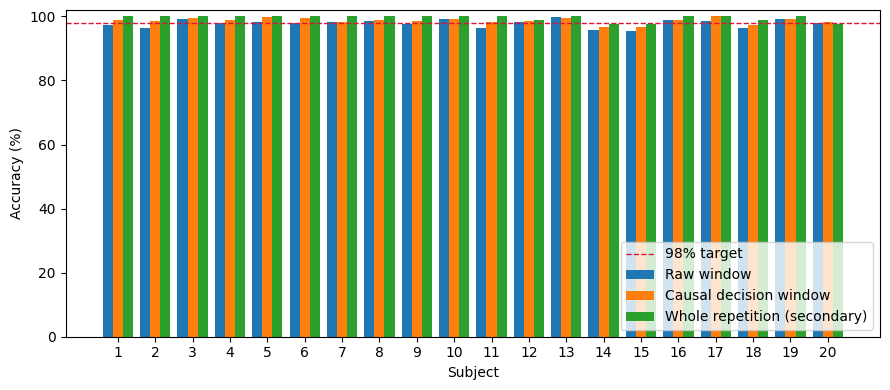

Results table: /kaggle/working/db7_results_v11/subject_results.csv
Summary: /kaggle/working/db7_results_v11/summary.json


In [6]:
import csv
import numpy as np
import matplotlib.pyplot as plt

result_root = Path(CFG.output_root)
summary = json.loads((result_root / 'summary.json').read_text())
for cohort, result in summary['cohorts'].items():
    primary = result['window']
    raw = result['raw_window']
    print(f"{cohort}: mean subject causal decision-window accuracy = {100 * primary['mean_subject_accuracy']:.2f}%")
    print(f"{cohort}: mean subject raw window accuracy = {100 * raw['mean_subject_accuracy']:.2f}%")
    print('98% causal decision-window target:', 'MET' if primary['mean_target_met'] else 'NOT MET')
    print('Every subject >=98%:', primary['all_subjects_target_met'])
    print(f"Secondary whole-repetition accuracy = {100 * result['whole_repetition']['mean_subject_accuracy']:.2f}%")

with (result_root / 'subject_results.csv').open() as f:
    rows = list(csv.DictReader(f))
x = np.arange(len(rows))
fig, ax = plt.subplots(figsize=(max(9, len(rows) * .45), 4))
ax.bar(x - .27, [100 * float(r['raw_window_accuracy']) for r in rows], .27, label='Raw window')
ax.bar(x, [100 * float(r['causal_window_accuracy']) for r in rows], .27, label='Causal decision window')
ax.bar(x + .27, [100 * float(r['whole_repetition_accuracy']) for r in rows], .27, label='Whole repetition (secondary)')
ax.axhline(98, color='crimson', linestyle='--', linewidth=1, label='98% target')
ax.set(xticks=x, xticklabels=[r['subject'] for r in rows], xlabel='Subject', ylabel='Accuracy (%)', ylim=(0, 102))
ax.legend(loc='lower right')
fig.tight_layout()
fig.savefig(result_root / 'accuracy_by_subject.png', dpi=160)
plt.show()
print('Results table:', result_root / 'subject_results.csv')
print('Summary:', result_root / 'summary.json')

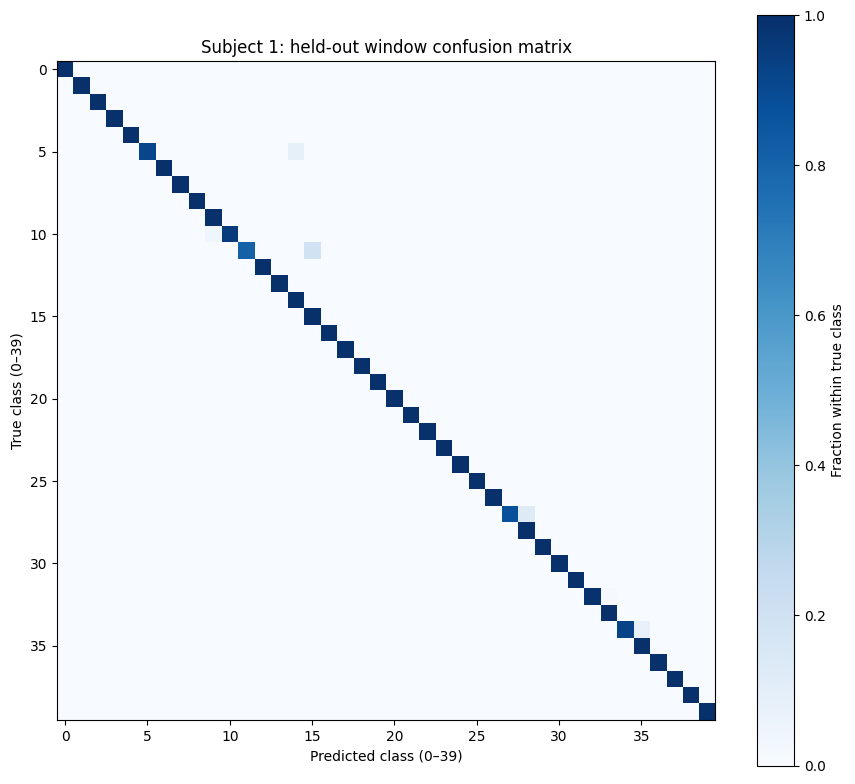

In [7]:
# Confusion matrix: rows=true class, columns=predicted class.
subject = CFG.subjects[0]
metrics = json.loads((result_root / f'subject_{subject:02d}' / 'metrics.json').read_text())
cm = np.asarray(metrics['confusion_matrix'])
cm_normalized = cm / np.maximum(cm.sum(axis=1, keepdims=True), 1)
fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(cm_normalized, cmap='Blues', vmin=0, vmax=1)
ax.set(title=f'Subject {subject}: held-out window confusion matrix', xlabel='Predicted class (0–39)', ylabel='True class (0–39)')
fig.colorbar(im, ax=ax, label='Fraction within true class')
fig.tight_layout()
fig.savefig(result_root / f'confusion_subject_{subject:02d}.png', dpi=160)
plt.show()

## Load the trained model for new windows

Load `Predictor(subject_dir)` once. Its `predict_proba(signals)` returns raw
per-window probabilities from raw,
synchronized arrays of shape `(window_samples, channels)` or
`(batch, window_samples, channels)`. Use the saved window length and selected
modalities. It does not accept labels or repetition IDs. Model outputs use classes
0–39; `model_manifest.json` maps them back to exercise and original labels.
Only load model files you trust. Example, after providing real sensor windows:

```python
predictor = Predictor('/kaggle/working/db7_results_v11/subject_01')
needed = predictor.selected['window_ms'] * 2  # 2,000 samples/second
probs = predictor.predict_proba({
    'emg': emg_window,    # needed x 12
    'acc': acc_window,    # needed x 36
    'gyro': gyro_window,  # needed x 36 (if selected)
    'mag': mag_window,    # needed x 36 (if selected)
})
predicted_class = int(probs[0].argmax())
original_label = predictor.manifest['label_map'][str(predicted_class)]
```

For the saved causal decision behavior, create `filter = predictor.new_trial_filter()`,
call `filter.update(probs[0])` for each chronological active window, and call
`filter.reset()` whenever the activity/trial segmenter ends a trial.

Files under each subject include validation selection/history, a window audit,
test predictions, model components, scaler, label mapping, and final metrics.
Download the result folder using Kaggle's Output panel after saving the version.

## Sources

- [Official DB7 instructions and downloads](https://ninapro.hevs.ch/instructions/DB7.html).
- [Krasoulis et al., 2017: original multimodal DB7 study](https://doi.org/10.1186/s12984-017-0284-4).
  This supports using concurrent EMG and inertial measurements; it does not
  establish the accuracy of this new implementation.
- [Cross-trial recognition study, Table 1](https://pmc.ncbi.nlm.nih.gov/articles/PMC10525369/):
  repetitions 1,3,4,6 for training and 2,5 for testing. This notebook reserves
  repetition 6 for development validation before the final refit.
- [Kaggle Python runtime source](https://github.com/Kaggle/docker-python).